In [1]:
import os


GITHUB_REPO = "https://github.com/KhaledMahaMudRajon/Convolutional-Neural-Networks.git"
STUDENT_ID  = "220110"


if not os.path.isdir("my_repo"):
    !git clone {GITHUB_REPO} my_repo

CUSTOM_IMG_DIR = "my_repo/dataset"
MODEL_OUT_DIR  = "my_repo/model"
os.makedirs(MODEL_OUT_DIR, exist_ok=True)

if not os.path.isdir("Fruit-Images-Dataset"):
    !git clone --depth 1 https://github.com/Horea94/Fruit-Images-Dataset.git

print("Custom images:", os.listdir(CUSTOM_IMG_DIR) if os.path.isdir(CUSTOM_IMG_DIR) else "MISSING - check GITHUB_REPO path")


Cloning into 'my_repo'...
remote: Enumerating objects: 80, done.
remote: Counting objects: 100% (80/80), done.
remote: Compressing objects: 100% (72/72), done.
remote: Total 80 (delta 15), reused 13 (delta 3), pack-reused 0 (from 0)
Receiving objects: 100% (80/80), 8.61 MiB | 20.70 MiB/s, done.
Resolving deltas: 100% (15/15), done.
Custom images: ['banana1.jpeg', 'banana.jpeg', 'apple2.jpeg', 'apple3.jpeg', '.gitkeep', 'apple1.jpeg', 'banana2.jpeg', 'apple.jpeg', 'orange1.jpeg', 'orange2.jpeg', 'orange.jpeg']


In [2]:
import glob, shutil, random


CLASSES = ["apple", "banana", "orange"]

SRC_ROOT = "Fruit-Images-Dataset/Training"
CLEAN_ROOT = "fruit_clean"

if os.path.isdir(CLEAN_ROOT):
    shutil.rmtree(CLEAN_ROOT)
os.makedirs(CLEAN_ROOT, exist_ok=True)
for c in CLASSES:
    os.makedirs(os.path.join(CLEAN_ROOT, c), exist_ok=True)

MAX_PER_CLASS = 1500

for c in CLASSES:
    matches = [d for d in os.listdir(SRC_ROOT) if d.lower().startswith(c)]
    count = 0
    for d in matches:
        folder = os.path.join(SRC_ROOT, d)
        for f in glob.glob(os.path.join(folder, "*.jpg")):
            if count >= MAX_PER_CLASS:
                break
            shutil.copy(f, os.path.join(CLEAN_ROOT, c, f"{d}_{os.path.basename(f)}"))
            count += 1
        if count >= MAX_PER_CLASS:
            break
    print(c, "->", count, "images")


apple -> 1500 images
banana -> 1430 images
orange -> 479 images


In [3]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, random_split

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

IMG_SIZE = 64

MEAN = [0.5, 0.5, 0.5]
STD  = [0.5, 0.5, 0.5]

train_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize(MEAN, STD),
])

eval_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(MEAN, STD),
])

full_dataset = datasets.ImageFolder(root=CLEAN_ROOT, transform=train_transform)
class_names = full_dataset.classes
print("Classes:", class_names)

val_ratio = 0.2
val_size = int(len(full_dataset) * val_ratio)
train_size = len(full_dataset) - val_size
train_dataset, val_dataset = random_split(full_dataset, [train_size, val_size],
                                           generator=torch.Generator().manual_seed(42))

val_dataset.dataset.transform = eval_transform

val_base = datasets.ImageFolder(root=CLEAN_ROOT, transform=eval_transform)
val_dataset = torch.utils.data.Subset(val_base, val_dataset.indices)

BATCH_SIZE = 64
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader   = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)

print(f"Train: {len(train_dataset)}  Val: {len(val_dataset)}")


Using device: cuda
Classes: ['apple', 'banana', 'orange']
Train: 2728  Val: 681


In [4]:
class CNN(nn.Module):
    def __init__(self, num_classes=3):
        super(CNN, self).__init__()
        self.conv1 = nn.Conv2d(3, 16, kernel_size=3, padding=1)
        self.conv2 = nn.Conv2d(16, 32, kernel_size=3, padding=1)
        self.conv3 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        self.relu = nn.ReLU()
        self.pool = nn.MaxPool2d(2, 2)

        flat_size = 64 * (IMG_SIZE // 8) * (IMG_SIZE // 8)

        self.fc1 = nn.Linear(flat_size, 128)
        self.dropout = nn.Dropout(0.3)
        self.fc2 = nn.Linear(128, num_classes)

    def forward(self, x):
        x = self.pool(self.relu(self.conv1(x)))
        x = self.pool(self.relu(self.conv2(x)))
        x = self.pool(self.relu(self.conv3(x)))
        x = torch.flatten(x, 1)
        x = self.relu(self.fc1(x))
        x = self.dropout(x)
        x = self.fc2(x)
        return x

model = CNN(num_classes=len(class_names)).to(device)
print(model)


CNN(
  (conv1): Conv2d(3, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv2): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv3): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (relu): ReLU()
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (fc1): Linear(in_features=4096, out_features=128, bias=True)
  (dropout): Dropout(p=0.3, inplace=False)
  (fc2): Linear(in_features=128, out_features=3, bias=True)
)


In [5]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

EPOCHS = 20

history = {"train_loss": [], "train_acc": [], "val_loss": [], "val_acc": []}

def run_epoch(loader, train=True):
    model.train() if train else model.eval()
    total_loss, correct, total = 0.0, 0, 0
    context = torch.enable_grad() if train else torch.no_grad()
    with context:
        for imgs, labels in loader:
            imgs, labels = imgs.to(device), labels.to(device)
            if train:
                optimizer.zero_grad()
            outputs = model(imgs)
            loss = criterion(outputs, labels)
            if train:
                loss.backward()
                optimizer.step()
            total_loss += loss.item() * imgs.size(0)
            preds = outputs.argmax(dim=1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)
    return total_loss / total, correct / total

for epoch in range(EPOCHS):
    tr_loss, tr_acc = run_epoch(train_loader, train=True)
    val_loss, val_acc = run_epoch(val_loader, train=False)

    history["train_loss"].append(tr_loss)
    history["train_acc"].append(tr_acc)
    history["val_loss"].append(val_loss)
    history["val_acc"].append(val_acc)

    print(f"Epoch {epoch+1}/{EPOCHS} | "
          f"Train Loss: {tr_loss:.4f} Acc: {tr_acc:.4f} | "
          f"Val Loss: {val_loss:.4f} Acc: {val_acc:.4f}")


Epoch 1/20 | Train Loss: 0.2133 Acc: 0.9241 | Val Loss: 0.1020 Acc: 0.9809
Epoch 2/20 | Train Loss: 0.0273 Acc: 0.9927 | Val Loss: 0.0004 Acc: 1.0000
Epoch 3/20 | Train Loss: 0.0012 Acc: 0.9996 | Val Loss: 0.0001 Acc: 1.0000
Epoch 4/20 | Train Loss: 0.0004 Acc: 1.0000 | Val Loss: 0.0000 Acc: 1.0000
Epoch 5/20 | Train Loss: 0.0001 Acc: 1.0000 | Val Loss: 0.0000 Acc: 1.0000
Epoch 6/20 | Train Loss: 0.0001 Acc: 1.0000 | Val Loss: 0.0000 Acc: 1.0000
Epoch 7/20 | Train Loss: 0.0001 Acc: 1.0000 | Val Loss: 0.0000 Acc: 1.0000
Epoch 8/20 | Train Loss: 0.0001 Acc: 1.0000 | Val Loss: 0.0000 Acc: 1.0000
Epoch 9/20 | Train Loss: 0.0001 Acc: 1.0000 | Val Loss: 0.0000 Acc: 1.0000
Epoch 10/20 | Train Loss: 0.0001 Acc: 1.0000 | Val Loss: 0.0000 Acc: 1.0000
Epoch 11/20 | Train Loss: 0.0000 Acc: 1.0000 | Val Loss: 0.0000 Acc: 1.0000
Epoch 12/20 | Train Loss: 0.0002 Acc: 1.0000 | Val Loss: 0.0000 Acc: 1.0000
Epoch 13/20 | Train Loss: 0.0012 Acc: 0.9993 | Val Loss: 0.0000 Acc: 1.0000
Epoch 14/20 | Train L

In [6]:
model_path = os.path.join(MODEL_OUT_DIR, f"{STUDENT_ID}.pth")
torch.save(model.state_dict(), model_path)
print("Saved:", model_path)


Saved: my_repo/model/220110.pth


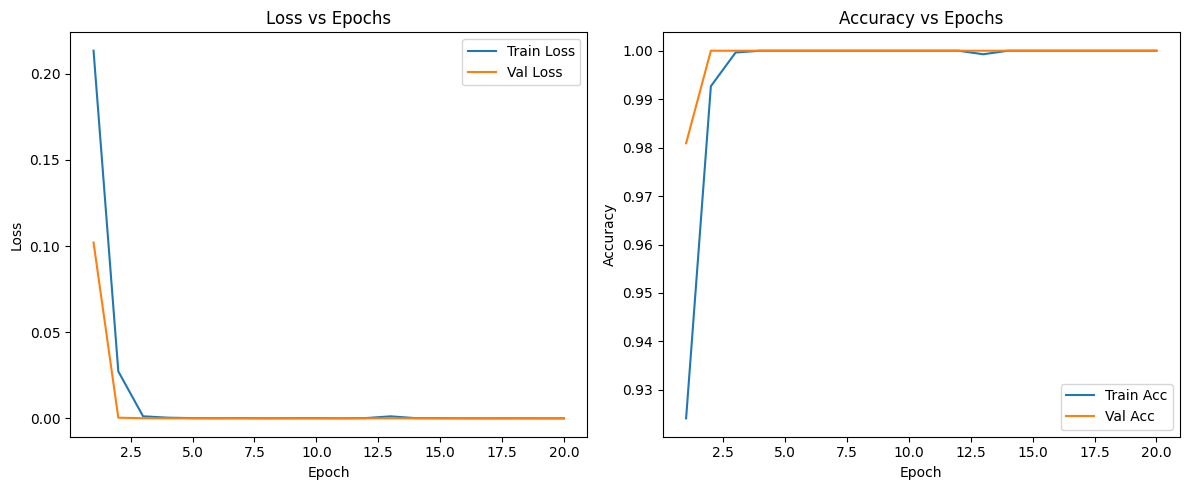

In [7]:
import matplotlib.pyplot as plt

epochs_range = range(1, EPOCHS + 1)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].plot(epochs_range, history["train_loss"], label="Train Loss")
axes[0].plot(epochs_range, history["val_loss"], label="Val Loss")
axes[0].set_title("Loss vs Epochs")
axes[0].set_xlabel("Epoch"); axes[0].set_ylabel("Loss")
axes[0].legend()

axes[1].plot(epochs_range, history["train_acc"], label="Train Acc")
axes[1].plot(epochs_range, history["val_acc"], label="Val Acc")
axes[1].set_title("Accuracy vs Epochs")
axes[1].set_xlabel("Epoch"); axes[1].set_ylabel("Accuracy")
axes[1].legend()

plt.tight_layout()
plt.savefig("training_history.png", dpi=150)
plt.show()


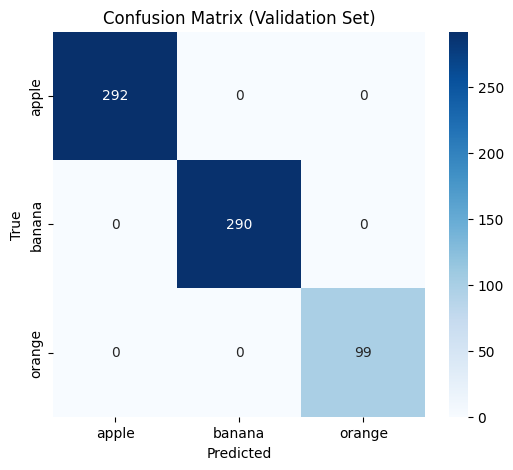

In [8]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import numpy as np

model.eval()
all_preds, all_labels = [], []
with torch.no_grad():
    for imgs, labels in val_loader:
        imgs = imgs.to(device)
        outputs = model(imgs)
        preds = outputs.argmax(dim=1).cpu().numpy()
        all_preds.extend(preds)
        all_labels.extend(labels.numpy())

cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=class_names, yticklabels=class_names)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix (Validation Set)")
plt.savefig("confusion_matrix.png", dpi=150)
plt.show()


In [9]:
from PIL import Image
import torch.nn.functional as F

def predict_image(img_path, model, transform, class_names):
    img = Image.open(img_path).convert("RGB")
    x = transform(img).unsqueeze(0).to(device)
    model.eval()
    with torch.no_grad():
        logits = model(x)
        probs = F.softmax(logits, dim=1)
        conf, pred_idx = torch.max(probs, dim=1)
    return img, class_names[pred_idx.item()], conf.item() * 100

custom_files = sorted(glob.glob(os.path.join(CUSTOM_IMG_DIR, "*")))
custom_files = [f for f in custom_files if f.lower().endswith((".jpg", ".jpeg", ".png"))]
print(f"Found {len(custom_files)} custom images:", custom_files)

results = []
for f in custom_files:
    img, pred_class, conf = predict_image(f, model, eval_transform, class_names)
    results.append((img, os.path.basename(f), pred_class, conf))


Found 10 custom images: ['my_repo/dataset/apple.jpeg', 'my_repo/dataset/apple1.jpeg', 'my_repo/dataset/apple2.jpeg', 'my_repo/dataset/apple3.jpeg', 'my_repo/dataset/banana.jpeg', 'my_repo/dataset/banana1.jpeg', 'my_repo/dataset/banana2.jpeg', 'my_repo/dataset/orange.jpeg', 'my_repo/dataset/orange1.jpeg', 'my_repo/dataset/orange2.jpeg']


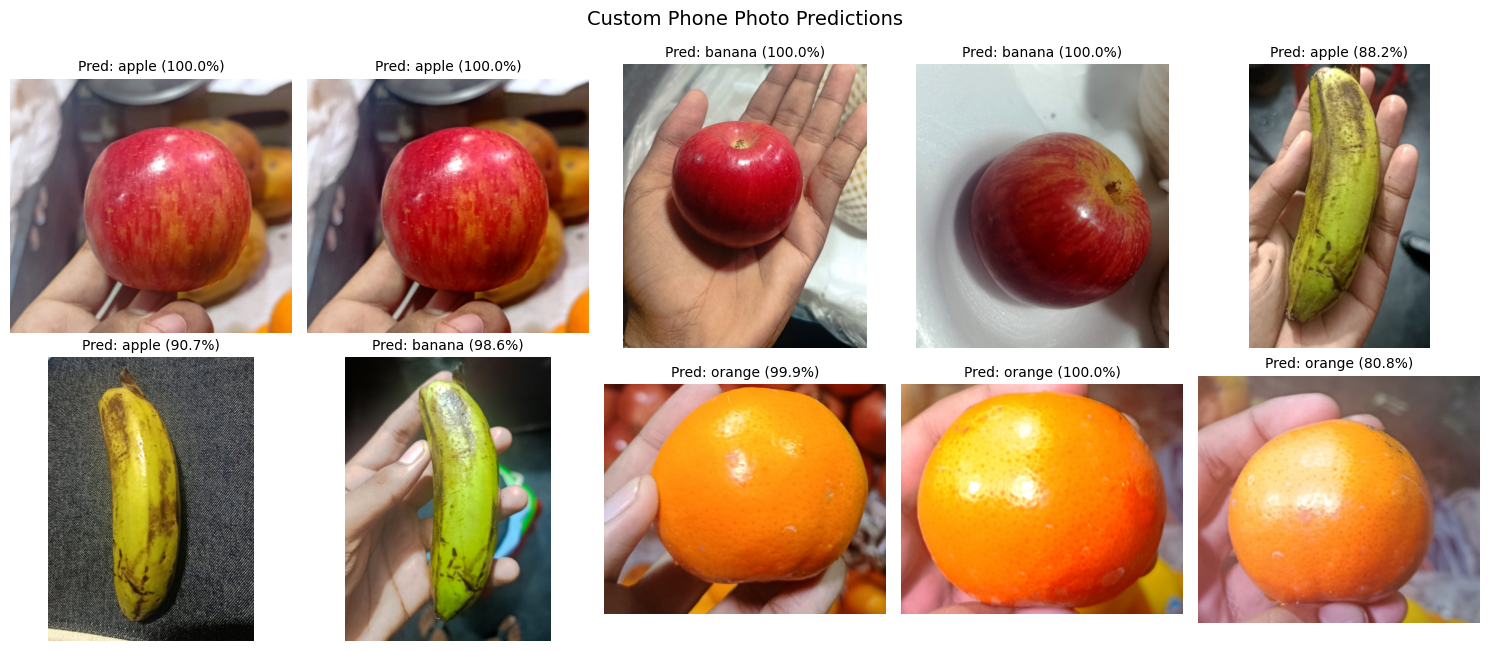

In [10]:
n = len(results)
cols = 5
rows = (n + cols - 1) // cols

fig, axes = plt.subplots(rows, cols, figsize=(cols * 3, rows * 3.3))
axes = axes.flatten() if n > 1 else [axes]

for i, (img, fname, pred_class, conf) in enumerate(results):
    axes[i].imshow(img)
    axes[i].set_title(f"Pred: {pred_class} ({conf:.1f}%)", fontsize=10)
    axes[i].axis("off")

for j in range(i + 1, len(axes)):
    axes[j].axis("off")

plt.suptitle("Custom Phone Photo Predictions", fontsize=14)
plt.tight_layout()
plt.savefig("custom_predictions_gallery.png", dpi=150)
plt.show()


In [11]:
wrong_indices = [i for i, (p, l) in enumerate(zip(all_preds, all_labels)) if p != l]
print(f"{len(wrong_indices)} misclassified out of {len(all_labels)} validation images")

if len(wrong_indices) == 0:
    print("No misclassified validation images — model got 100% on this split.")
else:
    sample_wrong = random.sample(wrong_indices, min(3, len(wrong_indices)))

    fig, axes = plt.subplots(1, len(sample_wrong), figsize=(4 * len(sample_wrong), 4))
    if len(sample_wrong) == 1:
        axes = [axes]

    for ax, idx in zip(axes, sample_wrong):
        img_tensor, true_label = val_dataset[idx]
        img_disp = img_tensor.permute(1, 2, 0).numpy()
        img_disp = img_disp * np.array(STD) + np.array(MEAN)
        img_disp = np.clip(img_disp, 0, 1)

        ax.imshow(img_disp)
        ax.set_title(f"True: {class_names[true_label]}\nPred: {class_names[all_preds[idx]]}", fontsize=10)
        ax.axis("off")

    plt.suptitle("Misclassified Examples")
    plt.tight_layout()
    plt.savefig("error_analysis.png", dpi=150)
    plt.show()

0 misclassified out of 681 validation images
No misclassified validation images — model got 100% on this split.


In [12]:
custom_results = []
for img, fname, pred_class, conf in results:
    true_class = None
    for c in class_names:
        if fname.lower().startswith(c):
            true_class = c
            break
    custom_results.append({
        "filename": fname,
        "true": true_class,
        "predicted": pred_class,
        "confidence": conf
    })

labeled = [r for r in custom_results if r["true"] is not None]
unlabeled = [r for r in custom_results if r["true"] is None]

if unlabeled:
    print(f"Warning: {len(unlabeled)} filename(s) didn't start with a class name, skipped from scoring:")
    for r in unlabeled:
        print("  -", r["filename"])

correct = sum(
    result["true"] == result["predicted"]
    for result in labeled
)
total = len(labeled)
custom_accuracy = 100 * correct / total if total > 0 else 0
print(f"\nCustom Image Accuracy: {custom_accuracy:.2f}%")
print(f"Correct: {correct}/{total}")


Custom Image Accuracy: 60.00%
Correct: 6/10


In [13]:
%cd /content/my_repo
!git config user.email "khaledmahamud26102004@gmail.com"
!git config user.name "KhaledMahaMudRajon"
!git add model/*.pth
!git commit -m "add trained model"
!git push
%cd /content

/content/my_repo
[main f3f6470] add trained model
 1 file changed, 0 insertions(+), 0 deletions(-)
 rewrite model/220110.pth (75%)
fatal: could not read Username for 'https://github.com': No such device or address
/content
